# 4. Ground and height

Classify ground returns, interpolate a terrain model, and turn elevations into
heights above ground.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import ground

cloud = synthetic.forest().without('classification')

## Ground classification

Two filters: the cloth simulation filter (CSF, Zhang et al. 2016) drapes a
cloth over the inverted cloud; the progressive morphological filter (PMF,
Zhang et al. 2003) opens a minimum surface with growing windows. CSF suits
multi-scan plots and open terrain, PMF copes better with single scans where
some cells have no ground return at all.

In [2]:
truth = synthetic.forest().attrs["classification"] == 2
for name, f in (("CSF", ground.classify_ground_csf), ("PMF", ground.classify_ground_pmf)):
    g = ground.ground_mask(f(cloud))
    print(f"{name}: {g.sum():,} ground points; recall {np.mean(g[truth]):.3f}, false positives {np.sum(g & ~truth):,}")
cloud = ground.classify_ground_csf(cloud)

CSF: 43,214 ground points; recall 1.000, false positives 3,214
PMF: 43,099 ground points; recall 1.000, false positives 3,099


## DTM and height normalisation

In [3]:
dtm = ground.make_dtm(cloud, resolution=0.5)
X, Y = dtm.cell_centers()
print("DTM", dtm.shape, "cells; RMSE against the true surface:",
      round(float(np.sqrt(np.nanmean((dtm.data - synthetic.terrain_height(X, Y)) ** 2))), 3), "m")
cloud = ground.normalize_height(cloud, dtm)          # adds the 'height' attribute
flat = ground.flatten(cloud, dtm)                    # or replace z itself

DTM (56, 56) cells; RMSE against the true surface: 0.024 m


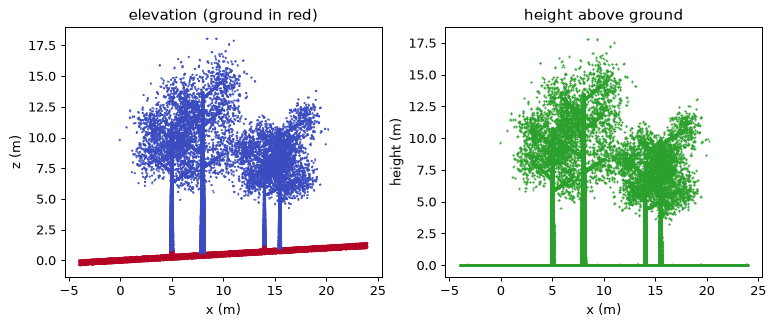

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].scatter(cloud.x[::5], cloud.z[::5], s=0.2, c=cloud.attrs["classification"][::5], cmap="coolwarm")
ax[0].set(title="elevation (ground in red)", xlabel="x (m)", ylabel="z (m)")
ax[1].scatter(cloud.x[::5], cloud.attrs["height"][::5], s=0.2, c="C2")
ax[1].set(title="height above ground", xlabel="x (m)", ylabel="height (m)");

## Canopy height model

canopy cover above 2 m: 0.226
tallest point: 17.84 m (the tallest stem is 15 m, with foliage above it)


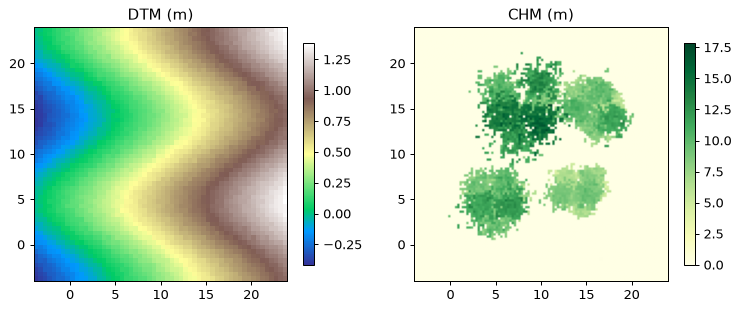

In [5]:
from sylva import canopy
chm = ground.make_chm(cloud, resolution=0.25)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, r, title, cmap in ((ax[0], dtm, "DTM (m)", "terrain"), (ax[1], chm, "CHM (m)", "YlGn")):
    im = a.imshow(r.data, origin="lower", extent=(r.xmin, r.xmax, r.ymin, r.ymax), cmap=cmap)
    a.set_title(title); fig.colorbar(im, ax=a, shrink=0.8)
print("canopy cover above 2 m:", round(canopy.canopy_cover(chm.data, 2.0), 3))
print("tallest point:", round(float(chm.data.max()), 2), "m (the tallest stem is 15 m, with foliage above it)")
chm.to_ascii_grid("chm.asc")   # or .to_geotiff() with rasterio